In [1]:

import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer
from glp.utils_acts import save_acts
from gemma2_pipeline.loading import iter_fineweb_texts, load_model_and_tokenizer
from gemma2_pipeline.preprocess import batch_items
from gemma2_pipeline.settings import FineWebSourceConfig

/mnt/disk1/aiotlab/envs/glp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible logical GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Logical cuda:0:", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES: 1
Visible logical GPUs: 1
Logical cuda:0: NVIDIA A30


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [33]:
# With CUDA_VISIBLE_DEVICES=2, physical GPU 2 is remapped to logical cuda:0.
device = "cuda:0"

# Your Gemma GLP checkpoint (local folder or HF repo id).
glp_name = "PQPQPQHUST/glp-gemma"
glp_ckpt = "1B/1000M"

# Gemma LLM setup for streaming reference activations and steering.
hf_model_name = "google/gemma-2-2b-it"
hf_layer = 14

In [24]:
import time

t0 = time.time()
try:
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}), falling back to online download.")
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
model = model.to(torch.bfloat16)
embedding_dim = model.denoiser.model.d_input
print(f"GLP loaded in {time.time() - t0:.1f}s | embedding_dim={embedding_dim}")
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Loaded GLP from local cache.
GLP loaded in 4.8s | embedding_dim=2304
Normalizer method: gaussian


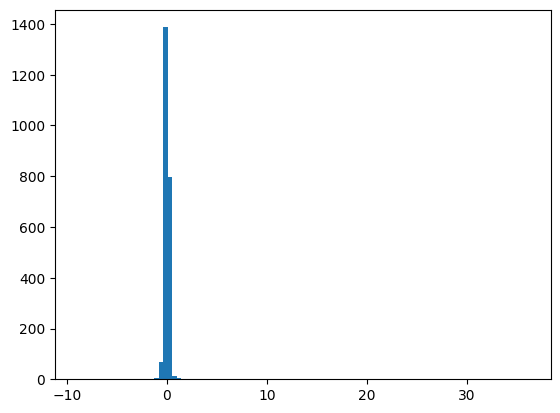

In [25]:
plt.hist(mean.cpu().numpy(), bins=100)
plt.show()

**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [34]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents


def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer,
    num_vectors=20000,
    dataset_name="HuggingFaceFW/fineweb",
    dataset_config="sample-10BT",
    split="train",
    text_field="text",
    max_documents=None,
    document_batch_size=16,
    forward_batch_size=1,
    max_length=1024,
    drop_bos=True,
):
    tracedict_config = {
        "layer_prefix": "model.layers",
        "layers": [layer],
        "retain": "output",
    }
    fineweb_cfg = FineWebSourceConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
        max_documents=max_documents,
    )

    text_iter = iter_fineweb_texts(fineweb_cfg)
    chunks = []
    vectors_written = 0
    for text_batch in tqdm(
        batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        acts = save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )
        vecs = acts[:, 0, :, :]
        if drop_bos and vecs.shape[1] > 1:
            vecs = vecs[:, 1:, :]
        vecs = vecs.reshape(-1, vecs.shape[-1])
        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - vectors_written
        vecs = vecs[:remaining]
        chunks.append(vecs.cpu())
        vectors_written += vecs.shape[0]
        if vectors_written >= num_vectors:
            break

    if vectors_written == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(chunks, dim=0)[:, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors.")
    return ref_latents



def compute_fd(ref_latents, gen_latents):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    ref_vecs = (ref_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    gen_vecs = (gen_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    return script_eval.rep_fd(ref_vecs[:n].float().numpy(), gen_vecs[:n].float().numpy())


def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps >= 10,
    )

In [35]:
from pathlib import Path

ref_num_vectors = 50000
ref_cache = Path(f"data/frechet-stream-{hf_model_name.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")

if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
else:
    print("Loading Gemma model for streaming references...")
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

Loading cached streamed reference activations from data/frechet-stream-gemma-2-2b-it-layer14-50000.pt


Below, you will see PCA plots for the generated vs streamed-reference activations.

The quantitative evaluation in the next section uses two separate pipelines:
- Fair quality: reference-fit IQR scaling, then multi-scale IMQ MMD
- Surgical attribution: raw 1D Wasserstein per dimension

If streaming is slow, reduce `ref_num_vectors` or `max_length` in the previous cell.

In [37]:
# Generation hyperparameters
batch_size = 10000
eval_timesteps = [1, 20]

# Legacy normalized FD is kept only as a comparison point.
legacy_fd_eval_vectors = min(batch_size, ref_latents.shape[0])

# MMD is O(n^2), so keep the fair-quality subset smaller.
quality_eval_vectors = min(2048, ref_latents.shape[0])
quality_block_size = 256

# Raw per-dimension Wasserstein is much cheaper, so we can inspect more points.
attribution_eval_vectors = min(4096, ref_latents.shape[0])

Generating activations...


1it [00:01,  1.10s/it]


Plotting PCA...
Generating activations...


20it [00:04,  4.25it/s]


Plotting PCA...


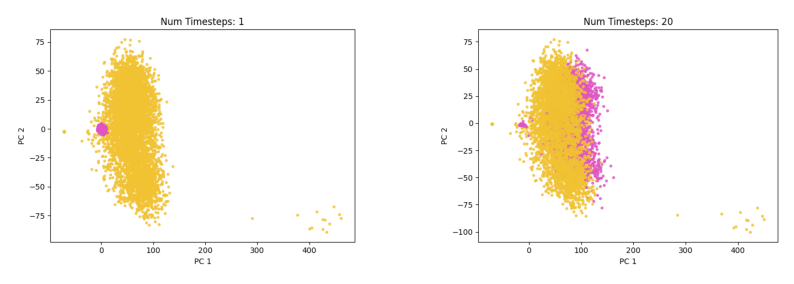

,frechet_distance
num_timesteps,
1,3600.92
20,2116.36


In [38]:
# run generation
generator = torch.Generator().manual_seed(4)
pca_plots = []
fd_rows = []
generated_latents_by_step = {}

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors]),
    })

# visualize the PCA results
plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

# show Frechet Distance summary
fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)


**Dimension-level Frechet attribution**

Full covariance Frechet Distance contains cross-dimensional covariance terms, so there is no unique exact per-dimension attribution. The diagnostic below uses the diagonal Gaussian decomposition, which is exact when dimensions are treated independently and is useful for finding high-variance dimensions that dominate the score.


In [ ]:
def _activation_vectors(latents):
    """Return [n, d] activation vectors on CPU float32 from [n, 1, d] or [n, d]."""
    vecs = latents.detach().cpu().float()
    if vecs.ndim == 3:
        vecs = vecs[:, 0, :]
    if vecs.ndim != 2:
        raise ValueError(f"Expected [n, d] or [n, 1, d], got {tuple(vecs.shape)}")
    return vecs


def _standardize_with_glp_stats(vecs):
    return (vecs - mean.detach().cpu().float()) / torch.sqrt(var.detach().cpu().float() + 1e-8)


def frechet_dimension_attribution(ref_latents, gen_latents, normalize=True, eps=1e-8):
    """Compute scalable per-dimension diagonal Frechet attribution.

    If normalize=True, attribution is in the same standardized space used by compute_fd().
    Raw variances are always included so high-variance Gemma dimensions can be related
    back to the distance contribution.
    """
    ref_raw = _activation_vectors(ref_latents)
    gen_raw = _activation_vectors(gen_latents)
    n = min(ref_raw.shape[0], gen_raw.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set.")
    ref_raw = ref_raw[:n]
    gen_raw = gen_raw[:n]

    ref = _standardize_with_glp_stats(ref_raw) if normalize else ref_raw
    gen = _standardize_with_glp_stats(gen_raw) if normalize else gen_raw

    ref_mu = ref.mean(dim=0)
    gen_mu = gen.mean(dim=0)
    ref_var = ref.var(dim=0, unbiased=True)
    gen_var = gen.var(dim=0, unbiased=True)

    mean_component = (ref_mu - gen_mu).pow(2)
    variance_component = (torch.sqrt(ref_var.clamp_min(eps)) - torch.sqrt(gen_var.clamp_min(eps))).pow(2)
    fd_diag_contribution = mean_component + variance_component

    ref_raw_var = ref_raw.var(dim=0, unbiased=True)
    gen_raw_var = gen_raw.var(dim=0, unbiased=True)
    ref_norm_var = _standardize_with_glp_stats(ref_raw).var(dim=0, unbiased=True)
    gen_norm_var = _standardize_with_glp_stats(gen_raw).var(dim=0, unbiased=True)

    df = pd.DataFrame({
        "dim": np.arange(ref.shape[1]),
        "fd_diag_contribution": fd_diag_contribution.numpy(),
        "fd_mean_component": mean_component.numpy(),
        "fd_variance_component": variance_component.numpy(),
        "ref_raw_var": ref_raw_var.numpy(),
        "gen_raw_var": gen_raw_var.numpy(),
        "ref_norm_var": ref_norm_var.numpy(),
        "gen_norm_var": gen_norm_var.numpy(),
        "ref_mean": ref_mu.numpy(),
        "gen_mean": gen_mu.numpy(),
    })
    df["fd_diag_share"] = df["fd_diag_contribution"] / df["fd_diag_contribution"].sum()
    df["raw_var_total"] = df["ref_raw_var"] + df["gen_raw_var"]
    df["norm_var_total"] = df["ref_norm_var"] + df["gen_norm_var"]
    df["raw_var_ratio_gen_ref"] = df["gen_raw_var"] / (df["ref_raw_var"] + eps)
    df["norm_var_ratio_gen_ref"] = df["gen_norm_var"] / (df["ref_norm_var"] + eps)
    return df.sort_values("fd_diag_contribution", ascending=False).reset_index(drop=True)


def summarize_fd_variance_relation(attr_df, top_k=25):
    corr_cols = [
        "ref_raw_var", "gen_raw_var", "raw_var_total",
        "ref_norm_var", "gen_norm_var", "norm_var_total",
        "fd_mean_component", "fd_variance_component",
    ]
    corr = attr_df[["fd_diag_contribution", *corr_cols]].corr(method="spearman")["fd_diag_contribution"].drop("fd_diag_contribution")
    display(pd.DataFrame({"spearman_corr_with_fd_attr": corr}).sort_values("spearman_corr_with_fd_attr", ascending=False))
    display(attr_df.head(top_k)[[
        "dim", "fd_diag_contribution", "fd_diag_share",
        "fd_mean_component", "fd_variance_component",
        "ref_raw_var", "gen_raw_var", "ref_norm_var", "gen_norm_var",
        "raw_var_ratio_gen_ref", "norm_var_ratio_gen_ref",
    ]])


def plot_fd_attribution_vs_variance(attr_df, variance_col="raw_var_total", top_k=20):
    fig, ax = plt.subplots(figsize=(7, 5))
    sizes = 20 + 600 * attr_df["fd_diag_share"].clip(lower=0)
    ax.scatter(attr_df[variance_col], attr_df["fd_diag_contribution"], s=sizes, alpha=0.45)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(variance_col)
    ax.set_ylabel("diagonal FD contribution")
    ax.set_title("Per-dimension variance vs Frechet attribution")
    for _, row in attr_df.head(top_k).iterrows():
        ax.annotate(int(row["dim"]), (row[variance_col], row["fd_diag_contribution"]), fontsize=8, alpha=0.8)
    plt.tight_layout()
    plt.show()


In [ ]:
# Choose which generated distribution to inspect.
attribution_timesteps = max(eval_timesteps)
attr_df = frechet_dimension_attribution(
    ref_latents[:fd_eval_vectors],
    generated_latents_by_step[attribution_timesteps][:fd_eval_vectors],
    normalize=True,  # same standardized space used by compute_fd()
)

print(f"Diagonal FD approximation for {attribution_timesteps} steps: {attr_df['fd_diag_contribution'].sum():.4f}")
print(f"Top 10 dimensions explain {100 * attr_df.head(10)['fd_diag_share'].sum():.2f}% of diagonal attribution")
print(f"Top 50 dimensions explain {100 * attr_df.head(50)['fd_diag_share'].sum():.2f}% of diagonal attribution")

summarize_fd_variance_relation(attr_df, top_k=30)
plot_fd_attribution_vs_variance(attr_df, variance_col="raw_var_total", top_k=20)
plot_fd_attribution_vs_variance(attr_df, variance_col="norm_var_total", top_k=20)


**On-Manifold Steering with GLP (Gemma-2-2B-it)**

Here we use a pre-computed Gemma steering vector and compare:
- normal generation
- steer only
- steer + GLP post-processing

In [ ]:
# If streaming references already loaded Gemma, reuse it.
if "hf_model" not in globals() or "hf_tokenizer" not in globals():
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
else:
    hf_model.to(device, torch_dtype=torch.bfloat16)
    hf_model.eval()
    print("Reusing existing Gemma model/tokenizer from earlier cells.")

In [ ]:
question = "Are you Gemma?"

seed = 42
max_new_tokens = 80
temperature = 0.0
alphas = torch.tensor([1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)

vector_path = "Vector/CAA/extracted/Gemma/refusal_response.pt"
glp_u = 0.5
glp_num_timesteps = 20

In [ ]:
layer_name = f"model.layers.{hf_layer}"

# Load one layer steering vector from a tensor or dict payload.
payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload['steering_vector'][hf_layer] if isinstance(payload, dict) else payload

if steer_vector is None:
    raise ValueError(f"Layer {hf_layer} not found in {vector_path}")
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)

chat_prompt = hf_tokenizer.apply_chat_template(
    [{"role": "user", "content": question}],
    tokenize=False,
    add_generation_prompt=True,
)

settings = {
    "No Intervention": (None, None),
    "Steer Only": (script_steer.addition_intervention, None),
    "Steer + GLP": (
        script_steer.addition_intervention,
        script_steer.postprocess_on_manifold_wrapper(
            model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

In [ ]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df